# Beating Andrej Karpathy's MLP Loss Value

Exercises from the Video:

<span style = "color:green;">- E01: Tune the hyperparameters of the training to beat my best validation loss of 2.2 </span>

I just increased the batch size slightly and kept all other parameters the same. This slightly increased the run time but meant that the calculated gradients were more reflective of the entire training set.

<span style = "color:green;"> - E02: I was not careful with the intialization of the network in this video. (1) What is the loss you'd get if the predicted probabilities at initialization were perfectly uniform? What loss do we achieve? (2) Can you tune the initialization to get a starting loss that is much more similar to (1)? </span>

<span style = "color:green;"> - E03: Read the Bengio et al 2003 paper, implement and try any idea from the paper. Did it work? </span>

We have already implemented the main methodology of this paper, I have changed the parameters and introduced the ablations to further understand how the context and Cdim effect the result.


**First I will just copy over the relevant code from Andrej's notebook, I will beat his loss by using the exact same method but I will attempt to tune the hyperparameters better**


In [10]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline
from tqdm import tqdm

In [11]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


Now we build the datasets. This differs from the Trigram and Bigram set-up slightly. The block_size variable sets how many characters of context the neural network gets as an input in order to predict the next sequential character - Andrej uses 3 context characters in order to stay consistent with the work of Bengio's word predictor, however this is a parameter we could change. 

In [50]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  # X - inputs, Y - labels
  X, Y = [], []
  for w in words:

    # adds zero characters, '.' , to the beginning of works to initialise them based on length of block size.
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


Next we define the parameters of the network. These are worth changing in order to try to minimise the loss function:

- g: The initial seed, keep fixed for reproducibility. Will have a random negligible effect on loss.

- C: This is the lookup table of weights that contains the dimensionality of the space the characters will be embedded in. It is (27, n), as there are 27 characters and 'n' is the number of dimensions of the embedded space. 

- W1 and b1: The weights and biases of the neurons in the 'hidden' tanh layer. The number of neurons in this layer is defined by the dimensionality of b1 and the second index of W1. 

- W2 and b2: The weights and biases of the softmax layer - which returns the *effective* counts. Takes the same number of inputs as there are neurons in the tanh layer and gives 27 outputs corresponding to the probabilities of each character. 

In [51]:
Cdim = 10
num_inputs = block_size * Cdim

g = torch.Generator().manual_seed(2147483647) # for reproducibility
# C = torch.randn((27, Cdim), generator=g)
# W1 = torch.randn((num_inputs, 200), generator=g)
# b1 = torch.randn(200, generator=g)
# W2 = torch.randn((200, 27), generator=g)
# b2 = torch.randn(27, generator=g)

C = torch.rand((27, Cdim), generator=g)
W1 = torch.empty(num_inputs, 200)
torch.nn.init.kaiming_uniform_(W1, nonlinearity='relu')
b1 = torch.rand(200, generator=g)
W2 = torch.empty(200, 27)
torch.nn.init.kaiming_uniform_(W2, nonlinearity='relu')
b2 = torch.rand(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [52]:
print(f"number of parameters in the network: {sum(p.nelement() for p in parameters)}")

number of parameters in the network: 11897


Set the parameters to require a gradient, an important step but probably easy to forget.

In [53]:
for p in parameters:
  p.requires_grad = True

Initialize the empty arrays for diagnostics separately, such that we can rerun training without wiping them out. 

In [54]:
lri = []
lossi = []
stepi = []

Training on minibatch, as it is far quicker and even though it doesn't not find the true gradient in the backward pass, it provides a good estimate. In general it is better to have something that isn't perfect that you can iterate and improve quickly, than get the correct gradient with the entire dataset but be unable to iterate through many steps and limit your training effectiveness. 

That being said, the size of the batch is something that we could change to try and beat Andrej's loss. 

In [55]:
for i in range(200000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (48,))

  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, num_inputs) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

The follwing plot is a useful diagnostic to determine how the loss is progressing through the training. 

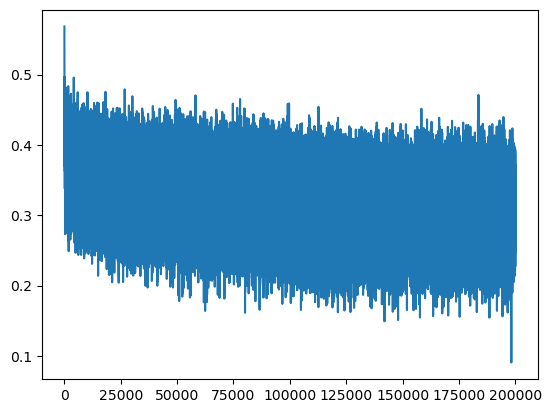

In [56]:
plt.plot(stepi, lossi)

Now we evaluate the loss, after training on the batch, on the entire training set and development set (this is often called the validation set)

In [57]:
# training loss
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, num_inputs) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0404, grad_fn=<NllLossBackward0>)

In [58]:
# validation loss
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, num_inputs) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.0989, grad_fn=<NllLossBackward0>)

The test set should **ONLY BE EVALUATED ONCE**. All model tuning should be done with the dev set, the test set is where we get the final loss without biasing the training. 

In [59]:
# test loss
emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1, num_inputs) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.0958, grad_fn=<NllLossBackward0>)

In [60]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmahzato.
harlin.
mir.
reet.
khalayson.
rahnin.
deliah.
jareen.
nellara.
chaiir.
kaleigh.
ham.
jois.
quintos.
lilea.
jadiquinterri.
jarynix.
kael.
drudi.
eddeli.


# Setting up an Abliation to study context length (block size) vs embedding dimension (Cdim)

First we define the constants we are using. 

In [4]:
N_STEPS    = 200000
BATCH_SIZE = 48
N_HIDDEN   = 200
LR_HIGH    = 0.1
LR_LOW     = 0.01
LR_SWITCH  = 100000   # step at which lr drops
SEED       = 2147483647


And develop previous functions to take additional arguments for block size.

In [5]:
def build_dataset(words, block_size):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X), torch.tensor(Y)


In [6]:
def make_params(block_size, Cdim, n_hidden=N_HIDDEN, vocab_size=27):
    g = torch.Generator().manual_seed(SEED)
    num_inputs = block_size * Cdim
 
    C  = torch.rand((vocab_size, Cdim), generator=g)
 
    W1 = torch.empty(num_inputs, n_hidden)
    torch.nn.init.kaiming_uniform_(W1, nonlinearity='relu')
 
    b1 = torch.rand(n_hidden, generator=g)
 
    W2 = torch.empty(n_hidden, vocab_size)
    torch.nn.init.kaiming_uniform_(W2, nonlinearity='relu')
 
    b2 = torch.rand(vocab_size, generator=g)
 
    params = [C, W1, b1, W2, b2]
    for p in params:
        p.requires_grad = True
    return params


Now we define a training function that rebuilds the datasets, trains the model and evaluates on the training and dev set, for each choice of block size and Cdim. 

In [12]:
def train_and_eval(block_size, Cdim, words):
    # rebuild datasets for this block_size
    import random
    random.seed(42)
    random.shuffle(words)
    n1 = int(0.8 * len(words))
    n2 = int(0.9 * len(words))
    Xtr, Ytr   = build_dataset(words[:n1],    block_size)
    Xdev, Ydev = build_dataset(words[n1:n2],  block_size)
 
    params = make_params(block_size, Cdim)
    C, W1, b1, W2, b2 = params
    num_inputs = block_size * Cdim
    lossi = []
 
    for i in tqdm(range(N_STEPS), mininterval=1.0):
        ix   = torch.randint(0, Xtr.shape[0], (BATCH_SIZE,))
        emb  = C[Xtr[ix]]
        h    = torch.tanh(emb.view(-1, num_inputs) @ W1 + b1)
        logits = h @ W2 + b2
        loss = F.cross_entropy(logits, Ytr[ix])
 
        for p in params:
            p.grad = None
        loss.backward()
 
        lr = LR_HIGH if i < LR_SWITCH else LR_LOW
        for p in params:
            p.data += -lr * p.grad
 
        lossi.append(loss.log10().item())
        pass
 
    # final evaluation (no grad needed)
    with torch.no_grad():
        emb  = C[Xtr];  h = torch.tanh(emb.view(-1, num_inputs) @ W1 + b1)
        train_loss = F.cross_entropy(h @ W2 + b2, Ytr).item()
 
        emb  = C[Xdev]; h = torch.tanh(emb.view(-1, num_inputs) @ W1 + b1)
        val_loss   = F.cross_entropy(h @ W2 + b2, Ydev).item()
 
    return train_loss, val_loss, lossi


First ablation: Vary the block size and keep Cdim = 10.

In [13]:
CDIM_FIXED = 10
BLOCK_SIZES = [2, 3, 4, 5, 6]

results_block = {}
for bs in BLOCK_SIZES:
    print(f"  block_size={bs}, Cdim={CDIM_FIXED} ...", end=" ", flush=True)
    tr, val, curve = train_and_eval(bs, CDIM_FIXED, words)
    results_block[bs] = (tr, val, curve)
    print(f"train={tr:.4f}  val={val:.4f}")


  block_size=2, Cdim=10 ... 

100%|██████████| 200000/200000 [02:07<00:00, 1565.64it/s]


train=2.2129  val=2.2315
  block_size=3, Cdim=10 ... 

100%|██████████| 200000/200000 [02:18<00:00, 1446.10it/s]


train=2.0408  val=2.1013
  block_size=4, Cdim=10 ... 

...

train=1.9531  val=2.0656
  block_size=5, Cdim=10 ... 

100%|██████████| 200000/200000 [02:51<00:00, 1168.25it/s]


train=1.9171  val=2.0373
  block_size=6, Cdim=10 ... 

100%|██████████| 200000/200000 [03:06<00:00, 1069.52it/s]


train=1.9003  val=2.0355


Second ablation: Vary Cdim and hold the block size.

In [14]:
BLOCK_FIXED = 3
CDIMS       = [2, 5, 10, 15, 20, 30]
 
results_cdim = {}
for cd in CDIMS:
    print(f"  block_size={BLOCK_FIXED}, Cdim={cd} ...", end=" ", flush=True)
    tr, val, curve = train_and_eval(BLOCK_FIXED, cd, words)
    results_cdim[cd] = (tr, val, curve)
    print(f"train={tr:.4f}  val={val:.4f}")


  block_size=3, Cdim=2 ... 

100%|██████████| 200000/200000 [01:40<00:00, 1999.56it/s]


train=2.2001  val=2.2114
  block_size=3, Cdim=5 ... 

100%|██████████| 200000/200000 [02:14<00:00, 1489.33it/s]


train=2.0953  val=2.1315
  block_size=3, Cdim=10 ... 

...

train=2.0144  val=2.1067
  block_size=3, Cdim=20 ... 

100%|██████████| 200000/200000 [04:00<00:00, 833.28it/s]


train=2.0015  val=2.0854
  block_size=3, Cdim=30 ... 

100%|██████████| 200000/200000 [05:16<00:00, 631.66it/s]


train=1.9924  val=2.0751


Now plotting

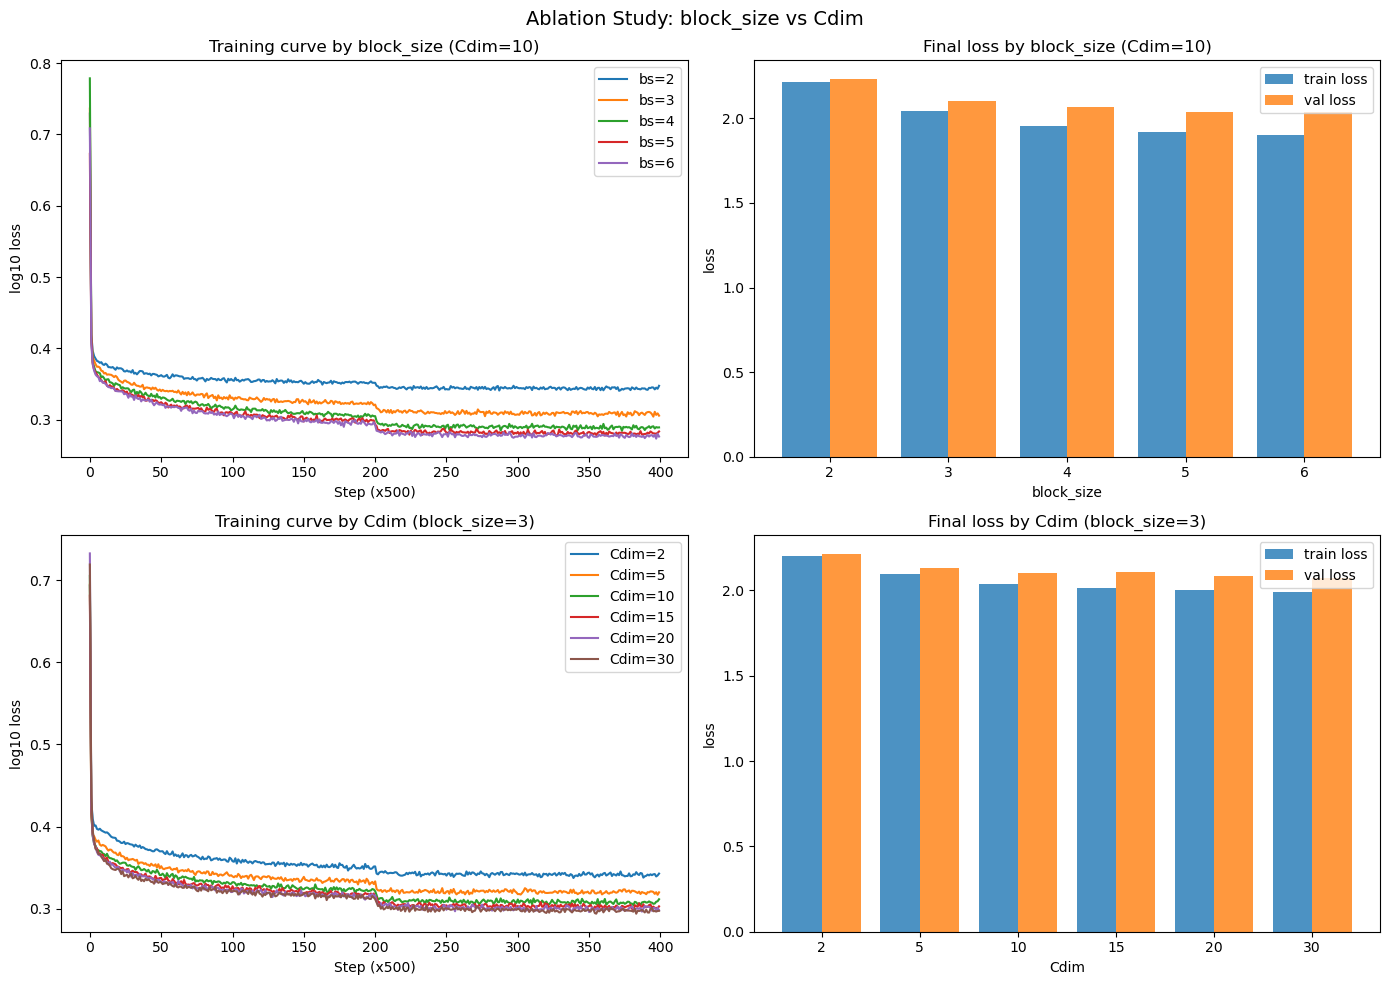

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Ablation Study: block_size vs Cdim", fontsize=14)
 
# --- Ablation 1: loss curves by block_size --------------------------------
ax = axes[0, 0]
smooth = 500   # rolling average window for readability
for bs, (_, _, curve) in results_block.items():
    smoothed = [sum(curve[max(0,i-smooth):i+1]) / len(curve[max(0,i-smooth):i+1])
                for i in range(0, len(curve), smooth)]
    ax.plot(smoothed, label=f"bs={bs}")
ax.set_title("Training curve by block_size (Cdim=10)")
ax.set_xlabel("Step (x500)")
ax.set_ylabel("log10 loss")
ax.legend()
 
# --- Ablation 1: final val loss bar chart ---------------------------------
ax = axes[0, 1]
bss  = list(results_block.keys())
vals = [results_block[bs][1] for bs in bss]
trs  = [results_block[bs][0] for bs in bss]
x    = range(len(bss))
ax.bar([i - 0.2 for i in x], trs,  width=0.4, label="train loss", alpha=0.8)
ax.bar([i + 0.2 for i in x], vals, width=0.4, label="val loss",   alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels([str(b) for b in bss])
ax.set_title("Final loss by block_size (Cdim=10)")
ax.set_xlabel("block_size")
ax.set_ylabel("loss")
ax.legend()
 
# --- Ablation 2: loss curves by Cdim --------------------------------------
ax = axes[1, 0]
for cd, (_, _, curve) in results_cdim.items():
    smoothed = [sum(curve[max(0,i-smooth):i+1]) / len(curve[max(0,i-smooth):i+1])
                for i in range(0, len(curve), smooth)]
    ax.plot(smoothed, label=f"Cdim={cd}")
ax.set_title("Training curve by Cdim (block_size=3)")
ax.set_xlabel("Step (x500)")
ax.set_ylabel("log10 loss")
ax.legend()
 
# --- Ablation 2: final val loss bar chart ---------------------------------
ax = axes[1, 1]
cds  = list(results_cdim.keys())
vals = [results_cdim[cd][1] for cd in cds]
trs  = [results_cdim[cd][0] for cd in cds]
x    = range(len(cds))
ax.bar([i - 0.2 for i in x], trs,  width=0.4, label="train loss", alpha=0.8)
ax.bar([i + 0.2 for i in x], vals, width=0.4, label="val loss",   alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels([str(c) for c in cds])
ax.set_title("Final loss by Cdim (block_size=3)")
ax.set_xlabel("Cdim")
ax.set_ylabel("loss")
ax.legend()
 
plt.tight_layout()
plt.show()


In [16]:
print("\n=== Ablation 1: block_size (Cdim=10) ===")
print(f"{'block_size':>12}  {'train_loss':>12}  {'val_loss':>10}")
for bs in BLOCK_SIZES:
    tr, val, _ = results_block[bs]
    print(f"{bs:>12}  {tr:>12.4f}  {val:>10.4f}")
 
print("\n=== Ablation 2: Cdim (block_size=3) ===")
print(f"{'Cdim':>12}  {'train_loss':>12}  {'val_loss':>10}")
for cd in CDIMS:
    tr, val, _ = results_cdim[cd]
    print(f"{cd:>12}  {tr:>12.4f}  {val:>10.4f}")



=== Ablation 1: block_size (Cdim=10) ===
  block_size    train_loss    val_loss
           2        2.2129      2.2315
           3        2.0408      2.1013
           4        1.9531      2.0656
           5        1.9171      2.0373
           6        1.9003      2.0355

=== Ablation 2: Cdim (block_size=3) ===
        Cdim    train_loss    val_loss
           2        2.2001      2.2114
           5        2.0953      2.1315
          10        2.0371      2.1039
          15        2.0144      2.1067
          20        2.0015      2.0854
          30        1.9924      2.0751


SO we can observe over-fitting with a large enough block size and with a higher embedding dimension. It seems the the increased context is more significant than the Cdim value on the loss function of the training set, but with 6 characters this is to be expected as many names will be completely contained within this block_size. Hence, the overfitting doesn't translate as well to the loss evaluated on the dev set. 

Looking at the log loss / steps plot, we see a clear drop in the loss corresponding to the change of learning rate. We should instead, continue to refine the learning rate as the process continues, to be sure we find the minima more precisely. 